# Part 3 - Advanced Machine Learning
In part one we achieved around 67% accuracy on GalaxyMNIST using a kNN-classifier. Ultimately our goal is to get the highest possible score on GalaxyMNIST which can most likely be achieved using Convolutional Neural Networks. It is good practice to compare against simple baselines when developing more complex models. In this notebook, we will start with simple non-neural network classifiers and then move on to fully connected and convolutional neural networks.

In [2]:
%load_ext autoreload
%autoreload 2
from IPython.display import display

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, gzip, requests

from torchvision import transforms
from torch.utils.data import DataLoader

import time

from Part03.device_management import get_device

# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1", "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))


transform = transforms.ToTensor()

train_dataset = GalaxyMNIST(root=root, train=True, transform=transform)
test_dataset = GalaxyMNIST(root=root, train=False, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=4)

DEVICE = get_device()
print(f'Using: {DEVICE}')

Using: cpu


## 3.1 Classical Algorithms
- Identify at least three classification algorithms that can be used for image classification.
- Explain briefly how they work and use them to classify the dataset. Use scikit-learn or other library implementations rather than implementing these yourself.
- Compare their metrics and runtime, which is best?

For possible algorithm options you can get inspired [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).

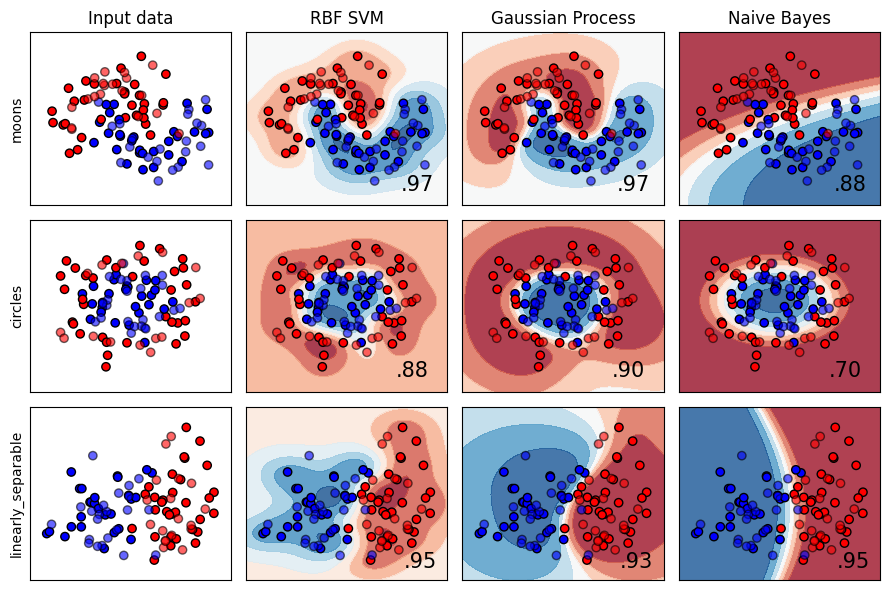

In [10]:
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from Part03.classical_algorithms import example_of_algorithms

classifiers_names = [
    "RBF SVM",
    "Gaussian Process",
    "Naive Bayes",
]
classifiers = [
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    GaussianNB(),
]

X, y = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]
datasets_names = [
    'moons',
    'circles',
    'linearly_separable',
]

# side effect -> plots everything
results = example_of_algorithms(
    classifiers,
    classifiers_names,
    datasets,
    datasets_names,
)

In [11]:
# create a dataframe of the results
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)
df["dataset"] = pd.Categorical(
    df["dataset"],
    categories=datasets_names,
    ordered=True
)

df.sort_values("classifier", inplace=True)

In [12]:
# create a desaturated cmap
cmap = plt.get_cmap("RdYlGn")
colors = cmap(np.linspace(0, 1, 256))
desat_factor = 0.8   # 0 = grayscale, 1 = original
gray = np.mean(colors[:, :3], axis=1, keepdims=True)
colors[:, :3] = gray + desat_factor * (colors[:, :3] - gray)
desat_cmap = ListedColormap(colors)

styled = (
    df.style
    .background_gradient(subset=["score"], cmap=desat_cmap)    # low scores red, high scores green
    .background_gradient(subset=["train_runtime"], cmap=desat_cmap.reversed())    # low runtime green, high runtime red
    .background_gradient(subset=["test_runtime"], cmap=desat_cmap.reversed())    # low runtime green, high runtime red
    .hide(axis='index')
)
display(styled)

classifier,dataset,score,train_runtime,test_runtime
RBF SVM,moons,0.975000,0.001758,0.000538
RBF SVM,circles,0.875000,0.000962,0.000459
RBF SVM,linearly_separable,0.950000,0.001120,0.000470
Gaussian Process,moons,0.975000,0.028128,0.000492
Gaussian Process,circles,0.900000,0.162853,0.000521
Gaussian Process,linearly_separable,0.925000,0.127723,0.000494
Naive Bayes,moons,0.875000,0.000880,0.006628
Naive Bayes,circles,0.700000,0.001533,0.000420
Naive Bayes,linearly_separable,0.950000,0.000942,0.000386


In [5]:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# for clf_cnt, (name, clf) in enumerate(zip(classifiers_names, classifiers)):
#     clf = make_pipeline(StandardScaler(), clf)
#     tr_st = time.perf_counter()
#     clf.fit(flattened_images, labels)
#     tr_et = time.perf_counter()
#     te_st = time.perf_counter()
#     score = clf.score(flattened_test_images, test_labels)
#     te_et = time.perf_counter()

#     tr_rt = tr_et - tr_st
#     te_rt = te_et - te_st
#     results.append({
#         'classifier': name,
#         'dataset': 'GalaxyMNIST', 
#         'score': score,
#         'train_runtime': tr_rt,
#         'test_runtime': te_rt
#     })

## 3.2 Neural Networks
We will now start to use neural networks to classify the GalaxyMNIST dataset.
### 3.2.1 Multi-Layer Perceptron (MLP)
In this task you will write all the infrastructure to train and evaluate a neural network on a dataset. We recommend using PyTorch, but you can use any other framework as well. You can use [this](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) tutorial to get started and follow the steps below:
- Define a torch dataset (use a `TensorDataset`) and data loaders for the dataset.
- Design a simple fully connected network.
- Write a training loop which computes output, loss and does an optimization step.
- Write an evaluation function that computes the predictions of the trained model on the test set. 
- Plot the training/test loss and accuracy against the number of epochs.


---



In [5]:
from torch import nn
import Part03.MLP_implementation as MLP
from Part03.NN_training import training_step

MLP_model = MLP.NeuralNetwork().to(DEVICE)
print(MLP_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(MLP_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        MLP_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 1.387417
Completed:  6464/ 8000    loss: 1.388501
Test Accuracy: 24.1 %    Test Avg. loss: 1.384528

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 1.389895
Completed:  6464/ 8000    loss: 1.376215
Test Accuracy: 31.7 %    Test Avg. loss: 1.378826

Done!


In [8]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,1.385007,0.252875,1.384528,0.241500
1,1.383153,0.262750,1.382873,0.269000
2,1.381586,0.300625,1.381860,0.303000
3,1.380210,0.317500,1.380238,0.322000
4,1.378969,0.327750,1.378826,0.317000
5,1.377832,0.317250,1.378019,0.318000
6,1.376785,0.326375,1.377432,0.317000
7,1.375751,0.307000,1.376542,0.319500


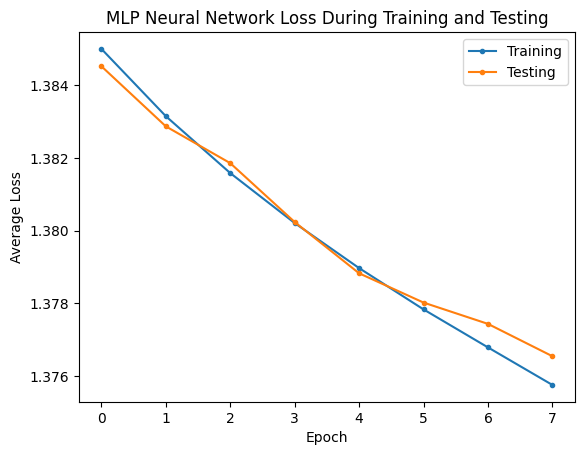

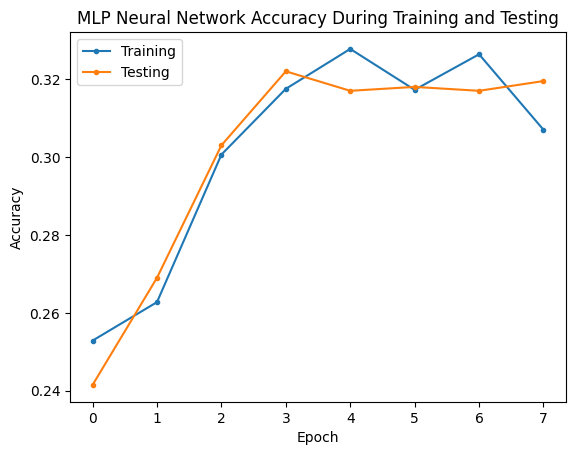

In [9]:
plt.plot(df['epoch'], df['training_avg_loss'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_avg_loss'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('MLP Neural Network Loss During Training and Testing')
plt.legend()
plt.show()

plt.plot(df['epoch'], df['training_accuracy'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_accuracy'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Neural Network Accuracy During Training and Testing')
plt.legend()
plt.show()

### 3.2.2  CNN
MLPs are a simple form of neural networks. However, inserting prior knowledge about the structure of the data can help improve the performance. Convolutional Neural Networks (CNNs) are a type of neural network that is well-suited for image classification tasks.
- Design a CNN and train it on the dataset.
- Can an MLP learn to act like a CNN?

In [3]:
import Part03.CNN_implementation as CNN

CNN_model = CNN.Neural_Network().to(DEVICE)
print(CNN_model)

Neural_Network(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(CNN_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        CNN_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 1.387438
Completed:  6464/ 8000    loss: 1.387672
Test Accuracy: 28.0 %    Test Avg. loss: 1.385869

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 1.383965
Completed:  6464/ 8000    loss: 1.385643
Test Accuracy: 36.9 %    Test Avg. loss: 1.384260

---------- Epoch 7 ----------
Completed:    64/ 8000    loss: 1.383925
Completed:  6464/ 8000    loss: 1.384263
Test Accuracy: 38.2 %    Test Avg. loss: 1.383372

Done!


In [7]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,1.386111,0.263125,1.385869,0.279500
1,1.385509,0.288500,1.385278,0.305000
2,1.385065,0.307125,1.384931,0.336000
3,1.384709,0.349125,1.384551,0.350500
4,1.384364,0.346750,1.384260,0.368500
5,1.384006,0.354375,1.383938,0.374500
6,1.383672,0.388625,1.383666,0.383500
7,1.383348,0.407000,1.383372,0.382000


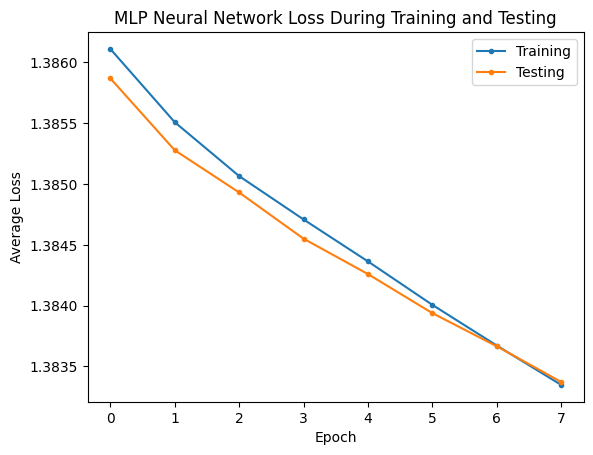

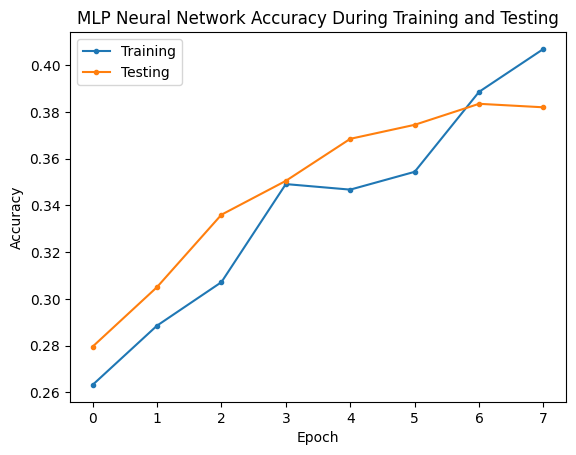

In [ ]:
plt.plot(df['epoch'], df['training_avg_loss'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_avg_loss'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('CNN Neural Network Loss During Training and Testing')
plt.legend()
plt.show()

plt.plot(df['epoch'], df['training_accuracy'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_accuracy'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Neural Network Accuracy During Training and Testing')
plt.legend()
plt.show()

## 3.2.3 Model Analysis
- Print how many parameters each neural network has.
- Does more parameters always mean better performance?

### 3.2.4 Hyperparameter Tuning
- Use your best model and try to improve its performance by changing its architecture. Possible changes include:
    - Normalization Layers
    - Regularization (Optimizer or Layers)
    - Different Activation Functions
    - Different Learning Rates
    - Increase the number of layers or neurons
- Report which changes seem effective and which do not.

### 3.2.5 Evaluation on the test set
You have now tuned the model hypterparameters to achieve the best accuracy on the test set.
- Why can it become problematic to tune hyperparameters on the test set? What are possible solutions to keep this overfitting in check?